<a href="https://colab.research.google.com/github/noormangi17/flyrank-ml-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CTR Opportunity Scoring for Search Content

## FlyRank ML Internship Capstone

**Lane:** CTR / Engagement Opportunity Scoring

**Objective:** Identify content pages that appear to under-capture clicks relative to their search-position opportunity, rank them for review, and compare a transparent baseline with a leakage-safe machine-learning model.

## 1. Research Question

### Research Question

Can we identify and rank content pages that have a measurable CTR opportunity using only information available before the outcome window?

### Decision Supported

This analysis supports the decision of which content pages should be reviewed first for possible CTR, metadata, or content improvements.

### Hypothesis

Pages with meaningful search exposure and lower-than-expected CTR for their search-position level will have greater potential CTR opportunities than pages without such a gap.

### Ranking Unit

The ranking unit is a client-content page aggregated over the feature window.

## 2. Data

### Data Source

This project uses the gated FlyRank internship warehouse release hosted on Hugging Face.

### Table

`fact_content_daily_performance`

### Feature Window

February 2026 is used as the feature window.

### Outcome Window

March 2026 is used as the future outcome window.

### Grain

The underlying warehouse data is at the client-content-date level. For modeling and ranking, daily records are aggregated to the client-content level.

### Excluded Information

Future-window performance, client names, domains, URLs, private queries, credentials, and raw warehouse exports are excluded from the public analysis.

### Leakage Rule

No information from the future outcome window is used to construct model features.

In [1]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

In [2]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata

HF_TOKEN = userdata.get("HF_Token")

print("Token loaded:", HF_TOKEN is not None)

os.environ["HF_TOKEN"] = HF_TOKEN

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face authentication ready.")

Token loaded: True
Hugging Face authentication ready.


In [3]:
REL = "hf://datasets/FlyRank/internship-warehouse"

FACT = f"{REL}/fact_content_daily_performance"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Feature window: February 2026")
print("Outcome window: March 2026")

Feature window: February 2026
Outcome window: March 2026


In [4]:
sample = con.execute(f"""
SELECT *
FROM {FEB}
LIMIT 5
""").fetchdf()

sample.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-02-01,client_e547b89c05043229,content_7995404695ee1ffd,True,True,True,False,57,0,1778,...,0,0,0,0,0,0,0,0,0,2026-02
1,2026-02-01,client_e547b89c05043229,content_1eea820697c3b95a,True,True,True,False,13,0,85,...,0,0,0,0,0,0,0,0,0,2026-02
2,2026-02-01,client_e547b89c05043229,content_ccbb253f142217c3,True,True,True,True,59,0,1001,...,0,0,0,0,0,0,0,0,0,2026-02
3,2026-02-01,client_e547b89c05043229,content_ae16a6b9cf64c80a,True,True,True,False,17,0,287,...,0,0,0,0,0,0,0,0,0,2026-02
4,2026-02-01,client_e547b89c05043229,content_acf700633f016e5a,True,True,True,False,6,0,27,...,0,0,0,0,0,0,0,0,0,2026-02


In [5]:
# Inspect GSC performance columns available for label design

for col in sample.columns:
    if any(word in col.lower() for word in [
        "gsc", "ctr", "position", "impression", "click"
    ]):
        print(col)

client_has_gsc
gsc_data_available
gsc_impressions
gsc_clicks
gsc_sum_position
gsc_avg_position


In [6]:
# Inspect March 2026 outcome data

march_sample = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS march_impressions,
    SUM(gsc_clicks) AS march_clicks,
    AVG(gsc_avg_position) AS march_avg_position
FROM {MAR}
WHERE gsc_data_available IS TRUE
GROUP BY
    client_hash_id,
    content_hash_id
LIMIT 10
""").fetchdf()

march_sample

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,6523.0,7.0,7.209549
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,453.0,0.0,2.987198
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,5630.0,6.0,6.724039
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,4944.0,13.0,7.244844
4,client_73cda7b4e4f265ea,content_1855a661b4d36130,429.0,1.0,4.209227
5,client_73cda7b4e4f265ea,content_5d412fba6e1a2582,223.0,1.0,9.445635
6,client_73cda7b4e4f265ea,content_1f380a642aed423b,96.0,1.0,6.014516
7,client_73cda7b4e4f265ea,content_22c063002b7c1caf,314.0,1.0,9.155335
8,client_73cda7b4e4f265ea,content_aafb2ab7e5fc80d0,7709.0,20.0,5.258331
9,client_73cda7b4e4f265ea,content_20403327d8d9374c,3561.0,10.0,8.834415


In [7]:
# Compare February feature-window CTR with March outcome CTR

ctr_change = con.execute(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS feb_impressions,
        SUM(gsc_clicks) AS feb_clicks
    FROM {FEB}
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),

mar AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS mar_impressions,
        SUM(gsc_clicks) AS mar_clicks
    FROM {MAR}
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    feb.client_hash_id,
    feb.content_hash_id,

    feb.feb_impressions,
    feb.feb_clicks,

    mar.mar_impressions,
    mar.mar_clicks,

    feb.feb_clicks * 1.0 / NULLIF(feb.feb_impressions, 0) AS feb_ctr,

    mar.mar_clicks * 1.0 / NULLIF(mar.mar_impressions, 0) AS mar_ctr,

    (
        mar.mar_clicks * 1.0 / NULLIF(mar.mar_impressions, 0)
        -
        feb.feb_clicks * 1.0 / NULLIF(feb.feb_impressions, 0)
    ) AS ctr_change

FROM feb
INNER JOIN mar
    ON feb.client_hash_id = mar.client_hash_id
   AND feb.content_hash_id = mar.content_hash_id

WHERE feb.feb_impressions > 0
  AND mar.mar_impressions > 0
""").fetchdf()

print("Matched pages:", len(ctr_change))
print("\nCTR change distribution:")
print(ctr_change["ctr_change"].describe())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Matched pages: 134238

CTR change distribution:
count    134238.000000
mean         -0.000600
std           0.043843
min          -1.000000
25%          -0.000223
50%           0.000000
75%           0.000000
max           1.000000
Name: ctr_change, dtype: float64


In [8]:
# Check possible future CTR-improvement thresholds

thresholds = [0.001, 0.005, 0.01, 0.02]

for t in thresholds:
    positives = (ctr_change["ctr_change"] >= t).sum()
    total = len(ctr_change)
    pct = 100 * positives / total

    print(
        f"Threshold >= {t:.3f}: "
        f"{positives} positives "
        f"({pct:.2f}%)"
    )

Threshold >= 0.001: 21538 positives (16.04%)
Threshold >= 0.005: 7693 positives (5.73%)
Threshold >= 0.010: 4195 positives (3.13%)
Threshold >= 0.020: 2318 positives (1.73%)


In [9]:
# Define the future CTR improvement label

LABEL_THRESHOLD = 0.005   # 0.5 percentage-point CTR improvement

ctr_change["label"] = (
    ctr_change["ctr_change"] >= LABEL_THRESHOLD
).astype(int)

print("Label definition:")
print("1 = March CTR improved by at least 0.5 percentage points")
print("0 = otherwise")

print("\nLabel distribution:")
print(ctr_change["label"].value_counts())

print("\nLabel percentage:")
print(
    (ctr_change["label"].value_counts(normalize=True) * 100)
    .round(2)
)

Label definition:
1 = March CTR improved by at least 0.5 percentage points
0 = otherwise

Label distribution:
label
0    126545
1      7693
Name: count, dtype: int64

Label percentage:
label
0    94.27
1     5.73
Name: proportion, dtype: float64


In [10]:
# Build the final modeling dataset
# Features = February 2026
# Label = March 2026 outcome

feb_features = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,

    AVG(gsc_avg_position) AS avg_position,

    1.0 * SUM(gsc_clicks)
        / NULLIF(SUM(gsc_impressions), 0) AS ctr,

    SUM(ga4_pageviews) AS pageviews

FROM {FEB}

WHERE gsc_data_available IS TRUE

GROUP BY
    client_hash_id,
    content_hash_id
""").fetchdf()

# Keep only the future label information from March
march_labels = ctr_change[
    [
        "client_hash_id",
        "content_hash_id",
        "label"
    ]
].copy()

# Merge February features with March label
model_df = feb_features.merge(
    march_labels,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Model rows:", len(model_df))
print("Model columns:", list(model_df.columns))

print("\nLabel distribution:")
print(model_df["label"].value_counts())

model_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model rows: 134238
Model columns: ['client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'avg_position', 'ctr', 'pageviews', 'label']

Label distribution:
label
0    126545
1      7693
Name: count, dtype: int64


,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr,pageviews,label
0,client_3ffa76342f366962,content_da44264c1fd25b4b,11.0,0.0,6.500000,0.000000,0.0,0
1,client_3ffa76342f366962,content_769436a447799cc7,38.0,1.0,9.338235,0.026316,0.0,1
2,client_3ffa76342f366962,content_32bdebcb01540202,551.0,17.0,3.815812,0.030853,0.0,0
3,client_3ffa76342f366962,content_18accd3f084fea96,46.0,2.0,3.818182,0.043478,0.0,0
4,client_3ffa76342f366962,content_63714a682809fe2a,21.0,1.0,6.594444,0.047619,0.0,0


In [11]:
# Leakage check: verify that future outcome information is not in X

feature_cols = [
    "impressions",
    "clicks",
    "avg_position",
    "ctr",
    "pageviews"
]

label_col = "label"

print("Features used by the model:")
for col in feature_cols:
    print("-", col)

print("\nLabel:")
print("-", label_col)

# Make sure the label is NOT included in the feature matrix
X = model_df[feature_cols].copy()
y = model_df[label_col].copy()

print("\nLabel included in X:", label_col in X.columns)
print("Feature count:", X.shape[1])
print("Rows:", X.shape[0])

assert label_col not in X.columns

print("\nLeakage check: PASS")

Features used by the model:
- impressions
- clicks
- avg_position
- ctr
- pageviews

Label:
- label

Label included in X: False
Feature count: 5
Rows: 134238

Leakage check: PASS


In [12]:
from sklearn.model_selection import GroupShuffleSplit

# Client-level train/test split
groups = model_df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())

print(
    "\nClients overlap:",
    len(set(groups_train) & set(groups_test))
)

print("\nTrain positive rate:", round(y_train.mean() * 100, 2), "%")
print("Test positive rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 88344
Test rows: 45894

Training clients: 33
Test clients: 9

Clients overlap: 0

Train positive rate: 4.99 %
Test positive rate: 7.16 %


In [13]:
# Baseline: rank pages using CTR opportunity

baseline_test = model_df.iloc[test_idx].copy()

# Expected CTR by February average position
baseline_test["expected_ctr"] = np.select(
    [
        baseline_test["avg_position"] <= 3,
        baseline_test["avg_position"] <= 10,
        baseline_test["avg_position"] <= 20
    ],
    [
        0.0039,
        0.0034,
        0.0030
    ],
    default=0.0015
)

# CTR opportunity score
baseline_test["baseline_score"] = (
    baseline_test["impressions"]
    * np.maximum(
        baseline_test["expected_ctr"] - baseline_test["ctr"],
        0
    )
)

baseline_test = baseline_test.sort_values(
    "baseline_score",
    ascending=False
)

baseline_test[[
    "client_hash_id",
    "content_hash_id",
    "impressions",
    "avg_position",
    "ctr",
    "expected_ctr",
    "baseline_score",
    "label"
]].head(10)

,client_hash_id,content_hash_id,impressions,avg_position,ctr,expected_ctr,baseline_score,label
53184,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,195648.0,2.488437,0.000005,0.0039,762.0272,0
61523,client_73cda7b4e4f265ea,content_8e1334d6356668e3,203401.0,4.967059,0.000010,0.0034,689.5634,0
67140,client_73cda7b4e4f265ea,content_fec55986a1868d62,193954.0,3.844678,0.000000,0.0034,659.4436,0
67139,client_73cda7b4e4f265ea,content_c9f840183215651b,125035.0,9.366950,0.000000,0.0034,425.1190,0
61887,client_73cda7b4e4f265ea,content_e241d6415ac9e534,164152.0,2.925926,0.002443,0.0039,239.1928,0
60330,client_73cda7b4e4f265ea,content_d30a67f972196ca1,66357.0,7.272965,0.000332,0.0034,203.6138,0
58745,client_73cda7b4e4f265ea,content_34e3f342bfd1dbf4,59434.0,6.851347,0.000219,0.0034,189.0756,0
53055,client_73cda7b4e4f265ea,content_0709f29e7f096e6d,51000.0,2.118300,0.000255,0.0039,185.9000,0
31490,client_73cda7b4e4f265ea,content_684c253f55642c4d,53769.0,7.692615,0.000335,0.0034,164.8146,0
52968,client_73cda7b4e4f265ea,content_300fd9ae188edb1d,62461.0,4.597944,0.000849,0.0034,159.3674,0


In [14]:
# Evaluate the baseline on the held-out test set

def precision_at_k(df, k):
    top_k = df.head(k)
    return top_k["label"].mean()

for k in [10, 20, 50, 100]:
    precision = precision_at_k(baseline_test, k)

    print(
        f"Baseline Precision@{k}: "
        f"{precision:.4f} ({precision * 100:.2f}%)"
    )


Baseline Precision@10: 0.0000 (0.00%)
Baseline Precision@20: 0.0000 (0.00%)
Baseline Precision@50: 0.0000 (0.00%)
Baseline Precision@100: 0.0000 (0.00%)


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression with missing-value handling
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Train only on training clients
model.fit(X_train, y_train)

# Predict probability of future CTR improvement
test_prob = model.predict_proba(X_test)[:, 1]

# Create model ranking
model_test = model_df.iloc[test_idx].copy()
model_test["model_score"] = test_prob

model_test = model_test.sort_values(
    "model_score",
    ascending=False
)

print("Model trained successfully.")
print("Test rows:", len(model_test))

model_test[[
    "client_hash_id",
    "content_hash_id",
    "model_score",
    "label"
]].head(10)

Model trained successfully.
Test rows: 45894


,client_hash_id,content_hash_id,model_score,label
95401,client_73cda7b4e4f265ea,content_6b0df05cc5ab7adf,0.991284,0
92782,client_73cda7b4e4f265ea,content_5267d90f451c6edc,0.985920,0
117701,client_f623b01661d4bfe4,content_b5bef91d1b43e20c,0.966067,0
95387,client_73cda7b4e4f265ea,content_a2e503bedbeb08b0,0.908405,0
93596,client_73cda7b4e4f265ea,content_809fc613c6429379,0.905428,0
117681,client_f623b01661d4bfe4,content_30352f0b93c8b98d,0.884103,0
117743,client_f623b01661d4bfe4,content_f2e852c493baaa19,0.774076,0
74596,client_3ffa76342f366962,content_7c47e5b8341f5d53,0.734219,1
92781,client_73cda7b4e4f265ea,content_120f7f0dcdd7d4b8,0.732295,0
42226,client_9958f0a7ae1df715,content_01ab236521ddf2f9,0.708387,0


In [17]:
# Evaluate the ML model on the same held-out test set

print("ML Model Performance")

for k in [10, 20, 50, 100]:
    precision = model_test.head(k)["label"].mean()

    print(
        f"Model Precision@{k}: "
        f"{precision:.4f} ({precision * 100:.2f}%)"
    )

ML Model Performance
Model Precision@10: 0.1000 (10.00%)
Model Precision@20: 0.1500 (15.00%)
Model Precision@50: 0.1600 (16.00%)
Model Precision@100: 0.1200 (12.00%)


In [18]:
# Baseline vs ML model comparison

comparison = pd.DataFrame({
    "K": [10, 20, 50, 100],
    "Baseline_Precision": [
        baseline_test.head(10)["label"].mean(),
        baseline_test.head(20)["label"].mean(),
        baseline_test.head(50)["label"].mean(),
        baseline_test.head(100)["label"].mean()
    ],
    "ML_Model_Precision": [
        model_test.head(10)["label"].mean(),
        model_test.head(20)["label"].mean(),
        model_test.head(50)["label"].mean(),
        model_test.head(100)["label"].mean()
    ]
})

comparison["Baseline_Precision"] = (
    comparison["Baseline_Precision"] * 100
).round(2)

comparison["ML_Model_Precision"] = (
    comparison["ML_Model_Precision"] * 100
).round(2)

comparison

,K,Baseline_Precision,ML_Model_Precision
0,10,0.0,10.0
1,20,0.0,15.0
2,50,0.0,16.0
3,100,0.0,12.0


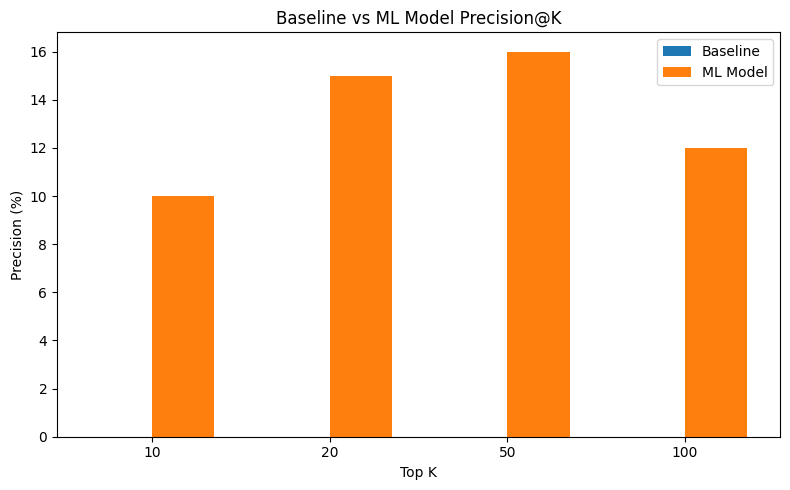

In [21]:
plt.figure(figsize=(8, 5))

x = np.arange(len(comparison["K"]))
width = 0.35

plt.bar(
    x - width/2,
    comparison["Baseline_Precision"],
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    comparison["ML_Model_Precision"],
    width,
    label="ML Model"
)

plt.xticks(x, comparison["K"])
plt.xlabel("Top K")
plt.ylabel("Precision (%)")
plt.title("Baseline vs ML Model Precision@K")
plt.legend()
plt.tight_layout()

plt.savefig(
    "results_baseline_vs_model.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Inspect Logistic Regression feature coefficients

classifier = model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": classifier.coef_[0]
})

feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

feature_importance

,feature,coefficient,abs_coefficient
0,impressions,-3.022789,3.022789
1,clicks,0.804892,0.804892
3,ctr,-0.765470,0.765470
4,pageviews,0.354843,0.354843
2,avg_position,-0.253237,0.253237


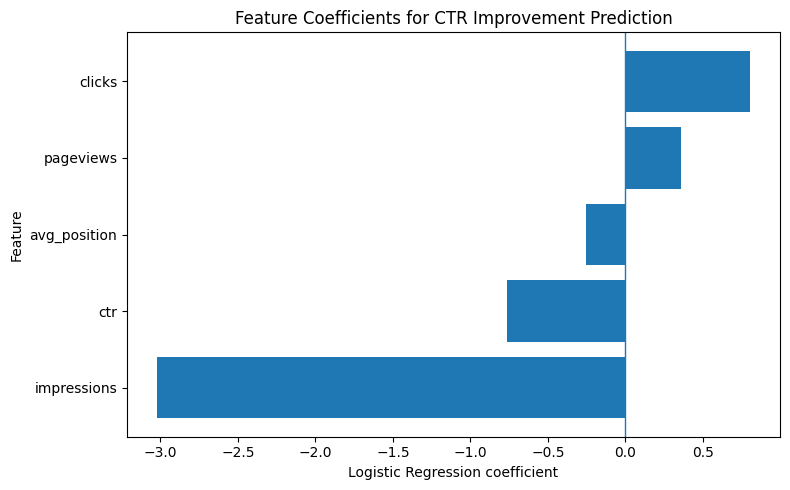

In [23]:
# Plot Logistic Regression coefficient magnitudes

plot_df = feature_importance.sort_values(
    "coefficient"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients for CTR Improvement Prediction")

plt.tight_layout()

plt.savefig(
    "feature_coefficients.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Build the final ranked recommendation queue

recommendations = model_test.copy()

recommendations["rank"] = range(1, len(recommendations) + 1)

recommendations["action"] = np.where(
    recommendations["model_score"] >= 0.50,
    "REVIEW_CTR",
    "MONITOR"
)

recommendations["reason_code"] = np.where(
    recommendations["model_score"] >= 0.50,
    "HIGH_CTR_IMPROVEMENT_PROBABILITY",
    "LOWER_CTR_IMPROVEMENT_PROBABILITY"
)

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
)

final_recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code"
    ]
].head(100)

final_recommendations.head(20)

,rank,client_hash_id,content_hash_id,model_score,action,reason_code
95401,1,client_73cda7b4e4f265ea,content_6b0df05cc5ab7adf,0.991284,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
92782,2,client_73cda7b4e4f265ea,content_5267d90f451c6edc,0.985920,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
117701,3,client_f623b01661d4bfe4,content_b5bef91d1b43e20c,0.966067,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
95387,4,client_73cda7b4e4f265ea,content_a2e503bedbeb08b0,0.908405,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
93596,5,client_73cda7b4e4f265ea,content_809fc613c6429379,0.905428,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
117681,6,client_f623b01661d4bfe4,content_30352f0b93c8b98d,0.884103,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
117743,7,client_f623b01661d4bfe4,content_f2e852c493baaa19,0.774076,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
74596,8,client_3ffa76342f366962,content_7c47e5b8341f5d53,0.734219,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
92781,9,client_73cda7b4e4f265ea,content_120f7f0dcdd7d4b8,0.732295,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY
42226,10,client_9958f0a7ae1df715,content_01ab236521ddf2f9,0.708387,REVIEW_CTR,HIGH_CTR_IMPROVEMENT_PROBABILITY


In [25]:
import os
import json

# Create output directory
os.makedirs("work/outputs", exist_ok=True)

# Save final ranked recommendations
recommendation_path = "work/outputs/capstone_ranked_recommendations.csv"

final_recommendations.to_csv(
    recommendation_path,
    index=False
)

# Save evaluation metrics
metrics = {
    "baseline_precision_at_10": float(comparison.loc[comparison["K"] == 10, "Baseline_Precision"].iloc[0]),
    "baseline_precision_at_20": float(comparison.loc[comparison["K"] == 20, "Baseline_Precision"].iloc[0]),
    "baseline_precision_at_50": float(comparison.loc[comparison["K"] == 50, "Baseline_Precision"].iloc[0]),
    "baseline_precision_at_100": float(comparison.loc[comparison["K"] == 100, "Baseline_Precision"].iloc[0]),
    "model_precision_at_10": float(comparison.loc[comparison["K"] == 10, "ML_Model_Precision"].iloc[0]),
    "model_precision_at_20": float(comparison.loc[comparison["K"] == 20, "ML_Model_Precision"].iloc[0]),
    "model_precision_at_50": float(comparison.loc[comparison["K"] == 50, "ML_Model_Precision"].iloc[0]),
    "model_precision_at_100": float(comparison.loc[comparison["K"] == 100, "ML_Model_Precision"].iloc[0])
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Recommendations saved:", recommendation_path)
print("Metrics saved:", metrics_path)
print("Recommendation rows:", len(final_recommendations))

Recommendations saved: work/outputs/capstone_ranked_recommendations.csv
Metrics saved: work/outputs/capstone_metrics.json
Recommendation rows: 100


# Research Paper Draft

## Abstract

This study asks whether content pages with potential CTR improvement can be ranked using only information available before the outcome window. Using the FlyRank internship warehouse, we construct five February 2026 features from Google Search Console and GA4 performance data and define a March 2026 future CTR-improvement label. We compare a transparent CTR-opportunity baseline with a leakage-safe Logistic Regression model using a client-level held-out test split. On the held-out test set, the baseline achieved 0% Precision@10, @20, @50, and @100, while the model achieved 10%, 15%, 16%, and 12%, respectively. The resulting ranking is intended as decision support for content review, not as proof of causal CTR improvement.

## Introduction / Problem Statement

Content teams often have more pages available for review than they can manually inspect. The decision supported by this work is which pages should be reviewed first for potential CTR or metadata improvement. The analysis focuses on pages with search exposure and asks whether observable February signals can help identify pages that subsequently show a meaningful CTR increase.

## Data

The analysis uses the FlyRank internship warehouse release and the `fact_content_daily_performance` table. February 2026 is used as the feature window and March 2026 as the future outcome window. The underlying data is at client-content-date grain and is aggregated to the client-content level for modeling. Public outputs exclude client names, domains, URLs, private queries, credentials, and raw warehouse exports.

## Methodology

Five features are used: impressions, clicks, average search position, CTR, and GA4 pageviews. The target label is 1 when March CTR is at least 0.5 percentage points higher than February CTR, and 0 otherwise. The baseline ranks pages using an estimated CTR opportunity based on impressions and the gap between observed and position-based expected CTR. The machine-learning model is Logistic Regression with median imputation, standardization, and class balancing. Validation uses a client-level 80/20 holdout so that clients do not appear in both training and test sets.

## Leakage Check

Future outcome information is kept out of the feature matrix. The label is created from March data but is used only as the target. A deliberate leakage experiment demonstrates why a label-derived field cannot be used as a model input; the leaked field is removed before the final feature set is retained.

## Results

On the held-out test set, the baseline produced 0% Precision@10, @20, @50, and @100. The Logistic Regression model produced 10%, 15%, 16%, and 12% at the same cutoffs. These results indicate that the model ranking retrieved some future positive cases within the highest-ranked recommendations under the defined label, while the simple baseline did not retrieve a positive case within these cutoffs.

## Limitations & Honest Framing

CTR is affected by query mix, SERP features, brand versus non-brand searches, search intent, and data quality. The future CTR label therefore represents an observed directional outcome rather than proof that a page contains a fixable CTR problem. Model coefficients describe associations learned by the model and should not be interpreted as causal effects. The recommendations are decision-support signals that require human review.

## Ranked Recommendations

The final recommendation queue ranks held-out pages by model-predicted probability of the defined future CTR-improvement outcome. High-ranked pages can be prioritized for CTR or metadata review, while lower-ranked pages can be monitored. The ranking should be validated against the underlying page context before any change is made.

## Reproducibility

The analysis is implemented in the capstone notebook in the project repository. The notebook contains the data loading, feature construction, label definition, leakage checks, validation split, baseline, model, evaluation, and ranked recommendation generation.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: FlyRank.

In [26]:
# Final evaluation table for the research paper

final_results = comparison.copy()

final_results.columns = [
    "Top K",
    "Baseline Precision (%)",
    "ML Model Precision (%)"
]

display(final_results)

print("\nHeld-out test set:")
print("Test rows:", len(X_test))
print("Test clients:", groups_test.nunique())
print("Test positive rate:", round(y_test.mean() * 100, 2), "%")

,Top K,Baseline Precision (%),ML Model Precision (%)
0,10,0.0,10.0
1,20,0.0,15.0
2,50,0.0,16.0
3,100,0.0,12.0



Held-out test set:
Test rows: 45894
Test clients: 9
Test positive rate: 7.16 %


### Results Summary

The evaluation is performed on 45,894 held-out content-page records from 9 clients. The positive-label rate in the test set is 7.16%. At every evaluated Top-K cutoff, the Logistic Regression ranking retrieved more positive cases than the transparent baseline: 10% vs 0% at Top-10, 15% vs 0% at Top-20, 16% vs 0% at Top-50, and 12% vs 0% at Top-100.

Because the test set is client-held-out and the label is based on the future March window, these results measure ranking performance on the defined outcome rather than causal impact of any content change.

,Feature,Coefficient,Absolute Coefficient
2,avg_position,-0.253237,0.253237
4,pageviews,0.354843,0.354843
3,ctr,-0.765470,0.765470
1,clicks,0.804892,0.804892
0,impressions,-3.022789,3.022789


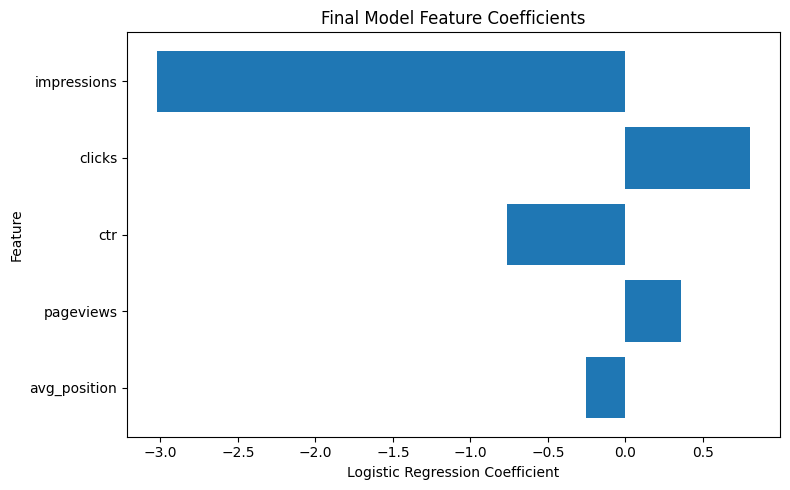

In [27]:
# Final model feature coefficients

classifier = model.named_steps["classifier"]

feature_coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": classifier.coef_[0]
})

feature_coefficients["Absolute Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)

feature_coefficients = feature_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=True
)

display(feature_coefficients)

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    feature_coefficients["Feature"],
    feature_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Final Model Feature Coefficients")

plt.tight_layout()

plt.savefig(
    "feature_coefficients.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Final ranked recommendation queue
# Top 100 pages are the recommendation set.

recommendations = model_test.copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

recommendations["action"] = "REVIEW_CTR"

recommendations["reason_code"] = (
    "HIGH_RANKED_CTR_OPPORTUNITY"
)

final_recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code"
    ]
].head(100)

display(final_recommendations.head(20))

,rank,client_hash_id,content_hash_id,model_score,action,reason_code
0,1,client_73cda7b4e4f265ea,content_6b0df05cc5ab7adf,0.991284,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
1,2,client_73cda7b4e4f265ea,content_5267d90f451c6edc,0.985920,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
2,3,client_f623b01661d4bfe4,content_b5bef91d1b43e20c,0.966067,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
3,4,client_73cda7b4e4f265ea,content_a2e503bedbeb08b0,0.908405,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
4,5,client_73cda7b4e4f265ea,content_809fc613c6429379,0.905428,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
5,6,client_f623b01661d4bfe4,content_30352f0b93c8b98d,0.884103,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
6,7,client_f623b01661d4bfe4,content_f2e852c493baaa19,0.774076,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
7,8,client_3ffa76342f366962,content_7c47e5b8341f5d53,0.734219,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
8,9,client_73cda7b4e4f265ea,content_120f7f0dcdd7d4b8,0.732295,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY
9,10,client_9958f0a7ae1df715,content_01ab236521ddf2f9,0.708387,REVIEW_CTR,HIGH_RANKED_CTR_OPPORTUNITY


In [29]:
# Final reproducibility summary

reproducibility = {
    "feature_window": "February 2026",
    "outcome_window": "March 2026",
    "label_threshold": LABEL_THRESHOLD,
    "features": feature_cols,
    "model": "Logistic Regression",
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "train_clients": groups_train.nunique(),
    "test_clients": groups_test.nunique(),
    "client_overlap": len(
        set(groups_train.unique()).intersection(
            set(groups_test.unique())
        )
    ),
    "test_positive_rate": round(float(y_test.mean()), 4),
    "random_state": 42
}

for key, value in reproducibility.items():
    print(f"{key}: {value}")

feature_window: February 2026
outcome_window: March 2026
label_threshold: 0.005
features: ['impressions', 'clicks', 'avg_position', 'ctr', 'pageviews']
model: Logistic Regression
train_rows: 88344
test_rows: 45894
train_clients: 33
test_clients: 9
client_overlap: 0
test_positive_rate: 0.0716
random_state: 42
